In [1]:
from pyscf import gto, scf, mp, ao2mo
import numpy as np
from pathlib import Path
# from py_mods.src.SCF.CSUHF import CS_UHF_ContextClass, CS_UHF
from py_mods.src.SCF.CSRHF import CS_RHF, CS_RHF_ContextClass
from py_mods.src.SCF.plot_utilities import plot_map
from Dev.CSMP2_dev import CS_MP2
# from Dev.naive_MP2 import CS_MP2
from py_mods.src.SCF.external import RHF_context_from_pyscf
import matplotlib.pyplot as plt 

In [2]:

large_basis = '''
He    S
      5.285000E+02           0.000000E+00           9.400000E-04           0.000000E+00           0.000000E+00
      7.931000E+01           0.000000E+00           7.214000E-03           0.000000E+00           0.000000E+00
      1.805000E+01           0.000000E+00           3.597500E-02           0.000000E+00           0.000000E+00
      5.085000E+00           0.000000E+00           1.277820E-01           0.000000E+00           0.000000E+00
      1.609000E+00           1.000000E+00           3.084700E-01           0.000000E+00           0.000000E+00
      5.363000E-01           0.000000E+00           4.530520E-01           1.000000E+00           0.000000E+00
      1.833000E-01           0.000000E+00           2.388840E-01           0.000000E+00           1.000000E+00
He    S
      0.0481900              1.0000000
He    P
      5.994000E+00           1.000000E+00           0.000000E+00           0.000000E+00
      1.745000E+00           0.000000E+00           1.000000E+00           0.000000E+00
      5.600000E-01           0.000000E+00           0.000000E+00           1.000000E+00
He    P
      0.1626000              1.0000000
He    D
      4.299000E+00           1.000000E+00           0.000000E+00
      1.223000E+00           0.000000E+00           1.000000E+00
He    D
      0.3510000              1.0000000
He    F
      2.680000E+00           1.0000000
He    F
      0.6906000              1.0000000
END
'''

converged SCF energy = -2.86152199563245


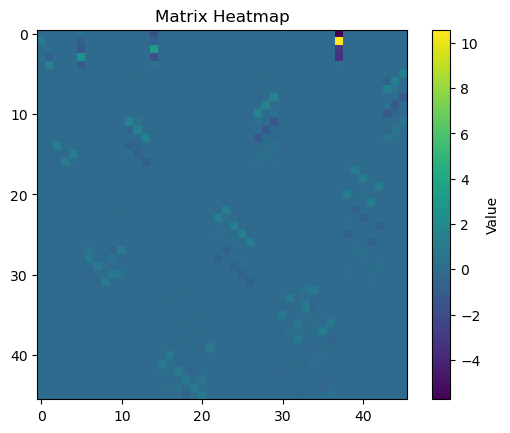

[ 1.00118477  0.63946381  0.86684257  0.90767732  1.127644    0.01377989
  0.81681233  0.82998201  1.05529029  0.91594115  1.09436329  0.37558452
  0.61841213  0.53944122 -0.12656163  1.13732289  1.16245604  0.7912072
  0.29470575  0.61035084  1.20554566  1.06508297  0.6709713   0.61068685
  0.64158394  0.48476531  0.54202914  0.51923741  0.58289176  0.71449678
  0.59762476  0.79005671  1.03031293  1.14343403  0.31091467  0.58522194
  0.16234275 -1.27673947  0.60153628  0.74666104  0.86867315  0.78713509
  0.70454202  0.35248064  0.74406566  0.63608828]


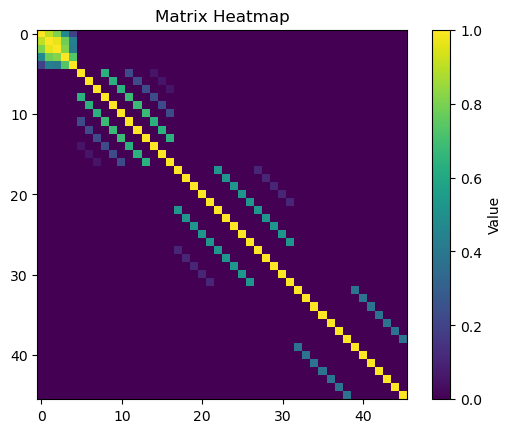

In [11]:
# pyscf data
pyscf_args = {
    'atom': 'He 0 0 0',
    'spin': 0,
    'charge': 0,
    'basis': 'aug-cc-pvqz',
}

mol = gto.M(**pyscf_args)
mol.basis = {'He': gto.basis.parse(large_basis)}
mol.build()

mf = scf.RHF(mol) 

e_He = mf.kernel()
e_elec = mf.energy_elec()

plot_map(mf.mo_coeff)
sum_cols = np.sum(mf.mo_coeff, axis=0)
print(sum_cols)
plot_map(mol.intor('int1e_ovlp'))
# mymp = mp.RMP2(mf).run() # this is UMP2

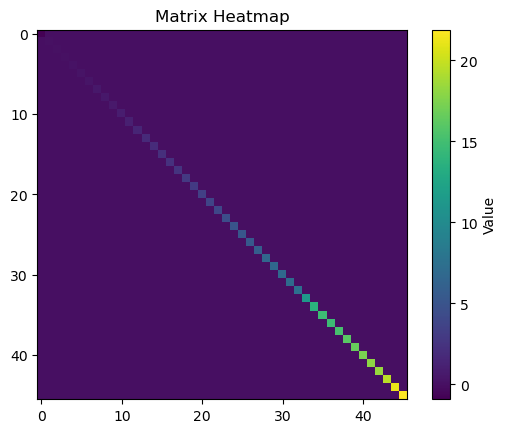

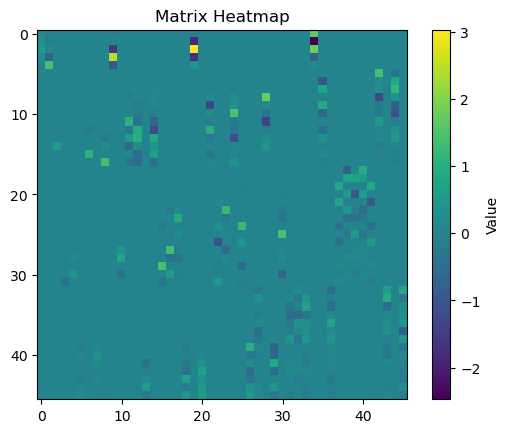

[ 1.16167116  0.61419842  0.42790029 -0.40158665  0.42362276 -0.13664925
  0.95406081  0.44705127  1.50675319 -0.10207629  0.70931598  0.5345732
  0.55738508  0.00233417 -0.36750297  0.99228264  1.31221782  0.61863716
  0.05321187 -0.21983399  2.20820714 -0.34714513 -0.36409764  0.49451493
  0.81646088  0.79212531  0.8891298  -0.44771369  0.59739336 -0.77575395
  0.38776284 -0.55506448 -0.32569397  1.19500402  0.41971865 -0.10922506
  0.27489941  1.01079032  0.33692207 -0.05178991  1.26997279 -0.04331547
  0.78598274  1.04032649  0.73365104  0.74852452]


In [12]:
# implementation and calculation
RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
RHF_cxt.theta = 0.00
RHF_cxt.occupation = np.array([2,0])
RHF_res = CS_RHF(RHF_cxt)

C_munu = RHF_res.R_munu.real
F_MO = RHF_res.R_munu.real.T @ RHF_res.F_final.real @ RHF_res.R_munu.real
plot_map(F_MO)
plot_map(C_munu)
sum_cols = np.sum(C_munu, axis=0)
print(sum_cols)

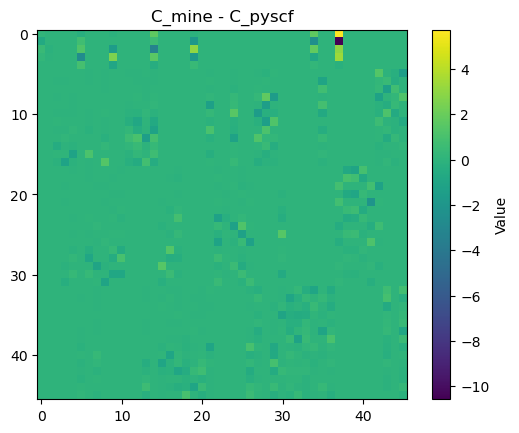

In [13]:
plot_map(C_munu - mf.mo_coeff, title='C_mine - C_pyscf')